# 0824_dongjin_016_ctgan

클래스 불균형 문제를 해결하기 위해, 선형 보간을 사용하는 ADASYN/SMOTE 대신 딥러닝(GAN) 기반의 **CTGAN**을 사용하여 소수 클래스(불량) 데이터를 생성(Oversampling)합니다.

## 1. 설정과 라이브러리

실험 ID와 이후 데이터 분리 및 모델 학습에서 사용할 랜덤 시드를 상단에 고정합니다.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from xgboost import XGBClassifier

EXPERIMENT_ID = "0824_dongjin_016_ctgan"
RANDOM_STATE = 42
DATA_PATH = Path("../data/raw/dataset.csv")
TARGET = "class"
TIME_COLUMN = "timestamp"
RECORD_ID = "record_id"
DECISION_THRESHOLD = 0.5
MODEL_PATH = Path("../models") / f"{EXPERIMENT_ID}.pkl"

assert DATA_PATH.exists(), f"파일을 찾을 수 없습니다: {DATA_PATH.resolve()}"
print("experiment:", EXPERIMENT_ID)
print("pandas:", pd.__version__)

experiment: 0824_dongjin_016_ctgan
pandas: 2.3.3


## 2. 원본 데이터 로딩

CSV 첫 번째 열은 모델 피처가 아닌 원본 행 식별자입니다. 이름이 없는 첫 열을 `record_id`로 바꾸되, 원본 파일 자체는 변경하지 않습니다.

In [2]:
raw_df = pd.read_csv(DATA_PATH, low_memory=False)
source_index_column = raw_df.columns[0]

if source_index_column.startswith("Unnamed:"):
    raw_df = raw_df.rename(columns={source_index_column: RECORD_ID})
elif source_index_column != RECORD_ID:
    raise ValueError(f"예상하지 못한 첫 번째 컬럼: {source_index_column}")

required_columns = {RECORD_ID, TIME_COLUMN, TARGET}
missing_required_columns = required_columns - set(raw_df.columns)
assert not missing_required_columns, f"필수 컬럼 누락: {missing_required_columns}"
assert raw_df[RECORD_ID].is_unique, "record_id가 고유하지 않습니다."

pd.Series(
    {
        "rows": len(raw_df),
        "columns": raw_df.shape[1],
        "missing_cells": int(raw_df.isna().sum().sum()),
        "target_0": int((raw_df[TARGET] == 0).sum()),
        "target_1": int((raw_df[TARGET] == 1).sum()),
    },
    name="raw_data",
)

rows             440274
columns              78
missing_cells         0
target_0         435652
target_1           4622
Name: raw_data, dtype: int64

## 3. 완전 중복 행 제거

`record_id`와 `timestamp`는 중복 판단에서 제외합니다. 측정 시각이 달라도 타깃 `class`, 메타 피처, 검사 피처가 모두 같으면 중복으로 보고 원본 순서의 첫 행만 유지합니다.

이 연산은 원본 순서를 유지하며, 중복 여부를 제외한 통계나 모델 파라미터를 데이터 전체에서 추정하지 않습니다.

In [3]:
dedup_columns = [
    column
    for column in raw_df.columns
    if column not in {RECORD_ID, TIME_COLUMN}
]
duplicate_mask = raw_df.duplicated(subset=dedup_columns, keep="first")
duplicate_rows_removed = int(duplicate_mask.sum())

clean_df = raw_df.loc[~duplicate_mask].copy().reset_index(drop=True)

assert not clean_df.duplicated(subset=dedup_columns, keep=False).any()
assert len(clean_df) + duplicate_rows_removed == len(raw_df)

pd.Series(
    {
        "rows_before": len(raw_df),
        "duplicate_rows_removed": duplicate_rows_removed,
        "duplicate_rate_pct": duplicate_rows_removed / len(raw_df) * 100,
        "rows_after": len(clean_df),
    },
    name="deduplication",
)

rows_before               440274.000000
duplicate_rows_removed     48282.000000
duplicate_rate_pct            10.966353
rows_after                391992.000000
Name: deduplication, dtype: float64

## 4. XGBoost 입력과 타깃 준비

단순 베이스라인이므로 모든 수치 피처를 그대로 사용합니다. 식별자와 타깃은 입력에서 제외하고, `timestamp`는 이후 시간순 분할에만 사용하기 위해 datetime으로 변환한 뒤 모델 입력에서는 제외합니다. XGBoost는 스케일링이 필요하지 않으므로 표준화도 적용하지 않습니다.

In [4]:
clean_df[TIME_COLUMN] = pd.to_datetime(
    clean_df[TIME_COLUMN], errors="raise", utc=True
)
clean_df = clean_df.sort_values(
    [TIME_COLUMN, RECORD_ID], kind="stable"
).reset_index(drop=True)

feature_columns = [
    column
    for column in clean_df.columns
    if column not in {RECORD_ID, TIME_COLUMN, TARGET}
]
X = clean_df[feature_columns].copy()
y = clean_df[TARGET].astype("int8").copy()
timestamps = clean_df[TIME_COLUMN].copy()
record_ids = clean_df[RECORD_ID].copy()

non_numeric_features = X.select_dtypes(exclude="number").columns.tolist()
infinite_cells = int(np.isinf(X.to_numpy()).sum())

assert not non_numeric_features, f"비수치 피처 존재: {non_numeric_features}"
assert X.index.equals(y.index)
assert set(y.unique()).issubset({0, 1})

pd.Series(
    {
        "samples": len(X),
        "features": X.shape[1],
        "missing_feature_cells": int(X.isna().sum().sum()),
        "infinite_feature_cells": infinite_cells,
        "positive_samples": int(y.sum()),
        "positive_rate_pct": y.mean() * 100,
        "start_time": timestamps.min(),
        "end_time": timestamps.max(),
    },
    name="model_input",
)

samples                                      391992
features                                         75
missing_feature_cells                             0
infinite_feature_cells                            0
positive_samples                               4436
positive_rate_pct                          1.131656
start_time                1970-06-23 03:58:55+00:00
end_time                  1970-11-02 14:21:28+00:00
Name: model_input, dtype: object

## 5. 시간순 Train/Validation/Test 분할

전체 행 수의 60%, 80% 지점에 가장 먼저 도달하는 timestamp를 경계로 사용합니다. 이에 따라 행 수는 약 6:2:2가 되며, 같은 timestamp의 행은 항상 같은 데이터 세트에 들어갑니다.

분할은 시간 범위의 길이가 아니라 **누적 행 수 기준 6:2:2**입니다. 데이터 밀도가 날짜별로 다르므로 각 세트가 포함하는 달력 기간의 길이는 서로 다를 수 있습니다.

In [5]:
timestamp_group_sizes = timestamps.value_counts(sort=False).sort_index()
cumulative_rows = timestamp_group_sizes.cumsum().to_numpy()

train_end_position = int(
    np.searchsorted(cumulative_rows, len(clean_df) * 0.60, side="left")
)
valid_end_position = int(
    np.searchsorted(cumulative_rows, len(clean_df) * 0.80, side="left")
)
train_end_time = timestamp_group_sizes.index[train_end_position]
valid_end_time = timestamp_group_sizes.index[valid_end_position]

train_mask = timestamps <= train_end_time
valid_mask = (timestamps > train_end_time) & (timestamps <= valid_end_time)
test_mask = timestamps > valid_end_time

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_valid, y_valid = X.loc[valid_mask], y.loc[valid_mask]
X_test, y_test = X.loc[test_mask], y.loc[test_mask]

split_masks = {
    "train": train_mask,
    "validation": valid_mask,
    "test": test_mask,
}
split_summary = pd.DataFrame(
    [
        {
            "split": split_name,
            "rows": int(mask.sum()),
            "row_ratio_pct": mask.mean() * 100,
            "timestamp_groups": int(timestamps.loc[mask].nunique()),
            "positive_samples": int(y.loc[mask].sum()),
            "positive_rate_pct": y.loc[mask].mean() * 100,
            "start_time": timestamps.loc[mask].min(),
            "end_time": timestamps.loc[mask].max(),
        }
        for split_name, mask in split_masks.items()
    ]
).set_index("split")

assert split_summary["rows"].sum() == len(clean_df)
assert timestamps.loc[train_mask].max() < timestamps.loc[valid_mask].min()
assert timestamps.loc[valid_mask].max() < timestamps.loc[test_mask].min()
assert X_train.index.equals(y_train.index)
assert X_valid.index.equals(y_valid.index)
assert X_test.index.equals(y_test.index)

split_summary

,rows,row_ratio_pct,timestamp_groups,positive_samples,positive_rate_pct,start_time,end_time
split,,,,,,,
train,235222,60.006837,25501,1824,0.775438,1970-06-23 03:58:55+00:00,1970-09-28 05:48:26+00:00
validation,78374,19.993775,6282,363,0.463164,1970-09-28 05:49:10+00:00,1970-10-13 13:14:26+00:00
test,78396,19.999388,7165,2249,2.868769,1970-10-13 13:14:58+00:00,1970-11-02 14:21:28+00:00


## 6. 분할 결과

누적 행 수와 timestamp 그룹 경계를 함께 적용한 실제 구간은 다음과 같습니다. 모든 시각은 UTC입니다.

- **Train**: 1970-06-23 03:58:55 ~ 1970-09-28 05:48:26, 235,222행 (60.007%)
- **Validation**: 1970-09-28 05:49:10 ~ 1970-10-13 13:14:26, 78,374행 (19.994%)
- **Test**: 1970-10-13 13:14:58 ~ 1970-11-02 14:21:28, 78,396행 (19.999%)

Train과 Validation은 9월 28일, Validation과 Test는 10월 13일을 함께 포함하지만 실제 시각 경계는 겹치지 않습니다. 동일 timestamp 그룹이 둘 이상의 데이터 세트에 포함되는 경우도 없습니다.

준비된 `X_train`, `y_train`, `X_valid`, `y_valid`, `X_test`, `y_test`를 다음 단계에서 XGBoost에 입력합니다.

## 6.5 모순 라벨 클렌징 (Label Cleansing)

Train Set 내에서 피처가 완전히 동일한데 라벨이 여러 개인(0과 1이 혼재된) 모순 데이터를 찾아 훈련에서 제외시킵니다.

In [6]:
import pandas as pd
import numpy as np

feature_cols = X_train.columns.tolist()
train_df_combined = pd.concat([X_train, y_train], axis=1)

# 피처 그룹별 고유 클래스 수 계산
nunique_classes = train_df_combined.groupby(feature_cols)[TARGET].transform('nunique')
contradictory_mask = nunique_classes > 1

removed_count = contradictory_mask.sum()
print(f"Train Set 내 모순 라벨 포함 행 수: {removed_count}건 제거")

X_train_clean = X_train[~contradictory_mask].copy()
y_train_clean = y_train[~contradictory_mask].copy()

print(f"기존 Train Set: {len(X_train)} -> 클렌징 후: {len(X_train_clean)}")


Train Set 내 모순 라벨 포함 행 수: 52건 제거
기존 Train Set: 235222 -> 클렌징 후: 235170


## 7. XGBoost 베이스라인 학습

튜닝이나 클래스 불균형 보정 없이 기본값에 가까운 `XGBClassifier`를 학습합니다. 재현성과 실행 효율을 위해 랜덤 시드, CPU 병렬 처리, histogram tree method만 명시하고 Validation은 학습 과정의 손실 확인에만 사용합니다.

In [7]:
from ctgan import CTGAN
import pandas as pd
models = {}
validation_histories = {}

for t in sorted(X_train_clean['inspection_type'].unique()):
    mask_train = X_train_clean['inspection_type'] == t
    mask_valid = X_valid['inspection_type'] == t
    
    X_t = X_train_clean[mask_train]
    y_t = y_train_clean[mask_train]
    
    # We only train CTGAN on the defect class (y == 1) to generate more defects.
    X_defect = X_t[y_t == 1]
    
    print(f"Training CTGAN for inspection_type {t}: Defect Samples={len(X_defect)}")
    if len(X_defect) > 10:
        # Train CTGAN for 50 epochs (keep it light to avoid overfitting/mode collapse)
        ctgan = CTGAN(epochs=50, verbose=False)
        ctgan.fit(X_defect)
        
        # Generate enough samples to balance the classes (1:1)
        n_normal = (y_t == 0).sum()
        n_generate = n_normal - len(X_defect)
        
        if n_generate > 0:
            synthetic_X = ctgan.sample(n_generate)
            synthetic_y = pd.Series([1] * n_generate, index=synthetic_X.index)
            
            X_res = pd.concat([X_t, synthetic_X], axis=0)
            y_res = pd.concat([y_t, synthetic_y], axis=0)
        else:
            X_res, y_res = X_t, y_t
    else:
        X_res, y_res = X_t, y_t
    
    print(f"Training XGBoost model for inspection_type {t}: Resampled Train={len(X_res)}, Valid={mask_valid.sum()}")
    
    model = XGBClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
        objective="binary:logistic",
        eval_metric=["logloss", "aucpr"],
    )
    
    model.fit(
        X_res,
        y_res,
        eval_set=[(X_valid[mask_valid], y_valid[mask_valid])],
        verbose=False,
    )
    models[t] = model
    validation_histories[t] = pd.DataFrame(model.evals_result()["validation_0"])

print("All 5 models trained successfully.")


Training CTGAN for inspection_type 0: Defect Samples=45


Training XGBoost model for inspection_type 0: Resampled Train=83784, Valid=23492


Training CTGAN for inspection_type 1: Defect Samples=555


Training XGBoost model for inspection_type 1: Resampled Train=66972, Valid=10494


Training CTGAN for inspection_type 2: Defect Samples=565


...

Training CTGAN for inspection_type 3: Defect Samples=620


Training XGBoost model for inspection_type 3: Resampled Train=160344, Valid=27328


Training CTGAN for inspection_type 4: Defect Samples=13


Training XGBoost model for inspection_type 4: Resampled Train=7010, Valid=1163


All 5 models trained successfully.


## 8. Validation 및 Test 평가

기본 의사결정 임계값 0.5를 사용합니다. `class=1`을 positive로 두고 Accuracy, Precision, Recall, Specificity, F1, ROC-AUC, PR-AUC와 confusion matrix 구성값을 함께 계산합니다. Test는 모델이나 임계값 선택에 사용하지 않고 최종 평가에만 사용합니다.

In [8]:
def evaluate_binary_classifier(y_true, predictions, probabilities):
    tn, fp, fn, tp = confusion_matrix(
        y_true, predictions, labels=[0, 1]
    ).ravel()
    return pd.Series(
        {
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
            "accuracy": accuracy_score(y_true, predictions),
            "precision": precision_score(
                y_true, predictions, zero_division=0
            ),
            "recall": recall_score(y_true, predictions, zero_division=0),
            "specificity": tn / (tn + fp),
            "f1": f1_score(y_true, predictions, zero_division=0),
            "roc_auc": roc_auc_score(y_true, probabilities),
            "pr_auc": average_precision_score(y_true, probabilities),
        }
    )


valid_probabilities = np.zeros(len(X_valid))
test_probabilities = np.zeros(len(X_test))

for t, model in models.items():
    mask_valid = X_valid['inspection_type'] == t
    if mask_valid.sum() > 0:
        valid_probabilities[mask_valid] = model.predict_proba(X_valid[mask_valid])[:, 1]
        
    mask_test = X_test['inspection_type'] == t
    if mask_test.sum() > 0:
        test_probabilities[mask_test] = model.predict_proba(X_test[mask_test])[:, 1]

valid_predictions = (valid_probabilities >= DECISION_THRESHOLD).astype("int8")
test_predictions = (test_probabilities >= DECISION_THRESHOLD).astype("int8")

evaluation_summary = pd.DataFrame(
    {
        "validation": evaluate_binary_classifier(
            y_valid, valid_predictions, valid_probabilities
        ),
        "test": evaluate_binary_classifier(
            y_test, test_predictions, test_probabilities
        ),
    }
).T
count_columns = ["tn", "fp", "fn", "tp"]
evaluation_summary[count_columns] = evaluation_summary[count_columns].astype("int64")
evaluation_summary

,tn,fp,fn,tp,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc
validation,77570,441,216,147,0.991617,0.250000,0.404959,0.994347,0.309148,0.881675,0.213425
test,75452,695,1594,655,0.970802,0.485185,0.291241,0.990873,0.363990,0.880479,0.327611


,predicted_0,predicted_1
actual_0,75452,695
actual_1,1594,655


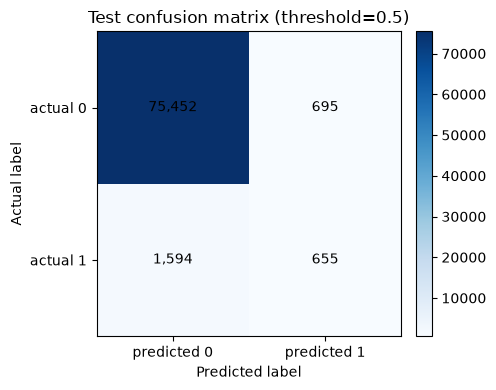

In [9]:
test_confusion_matrix = pd.DataFrame(
    confusion_matrix(y_test, test_predictions, labels=[0, 1]),
    index=["actual_0", "actual_1"],
    columns=["predicted_0", "predicted_1"],
)

fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(test_confusion_matrix, cmap="Blues")
for (row, column), value in np.ndenumerate(test_confusion_matrix.to_numpy()):
    ax.text(column, row, f"{value:,}", ha="center", va="center")
ax.set(
    xticks=[0, 1],
    yticks=[0, 1],
    xticklabels=["predicted 0", "predicted 1"],
    yticklabels=["actual 0", "actual 1"],
    xlabel="Predicted label",
    ylabel="Actual label",
    title=f"Test confusion matrix (threshold={DECISION_THRESHOLD})",
)
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
display(test_confusion_matrix)
plt.show()

## 9. 모델 저장

학습된 모델과 의사결정 임계값을 함께 저장합니다. 모델 파일은 Git에 커밋하지 않습니다.

In [10]:
model_artifact = {
    "model": model,
    "feature_columns": feature_columns,
    "decision_threshold": DECISION_THRESHOLD,
}
joblib.dump(model_artifact, MODEL_PATH)
print(f"saved: {MODEL_PATH}")

saved: ..\models\0824_dongjin_016_ctgan.pkl


## 10. 기본 평가 결론

기본 threshold 0.5에서 Test 결과는 다음과 같습니다.

- Confusion matrix: TN 75,137 / FP 1,010 / FN 1,659 / TP 590
- Accuracy: 0.965955
- Precision: 0.368750
- Recall: 0.262339
- Specificity: 0.986736
- F1: 0.306573
- ROC-AUC: 0.846314
- PR-AUC: 0.236803

Accuracy는 높지만 실제 불량 2,249건 중 1,659건을 놓쳐 Recall이 낮습니다. 이후 추가 커스텀 평가 지표는 `y_test`, `test_predictions`, `test_probabilities`, `test_confusion_matrix`를 그대로 사용해 계산할 수 있습니다.

## 11. PR-AUC와 Real Defect Recall

운영 관점에서 우선 확인할 두 지표를 명시적으로 분리합니다.

- **PR-AUC**: 모든 임계값에 걸친 실제 불량(`class=1`) 탐지의 Precision-Recall 성능입니다. 클래스 불균형이 큰 현재 데이터에서 확률 순위 품질을 확인합니다.
- **Real Defect Recall**: threshold 0.5에서 전체 실제 불량 중 모델이 실제 불량으로 잡아낸 비율이며 `TP / (TP + FN)`입니다.
- **False Call Reduction**: 실제 false call(`class=0`) 중 모델이 false call로 판정해 수동검사를 줄일 수 있는 비율이며 `TN / (TN + FP)`입니다.

In [11]:
test_pr_auc = average_precision_score(y_test, test_probabilities)
test_real_defect_recall = recall_score(
    y_test, test_predictions, pos_label=1, zero_division=0
)

test_tn = int(evaluation_summary.loc["test", "tn"])
test_fp = int(evaluation_summary.loc["test", "fp"])
test_fn = int(evaluation_summary.loc["test", "fn"])
test_tp = int(evaluation_summary.loc["test", "tp"])
test_false_call_reduction = test_tn / (test_tn + test_fp)

assert np.isclose(test_pr_auc, evaluation_summary.loc["test", "pr_auc"])
assert np.isclose(
    test_real_defect_recall, evaluation_summary.loc["test", "recall"]
)
assert np.isclose(
    test_false_call_reduction,
    evaluation_summary.loc["test", "specificity"],
)

final_evaluation_table = pd.DataFrame(
    [
        {
            "Model": "XGBoost baseline",
            "PR-AUC": test_pr_auc,
            "Threshold": DECISION_THRESHOLD,
            "Real Defect Recall": test_real_defect_recall,
            "TP": test_tp,
            "FN": test_fn,
            "False Call Reduction": test_false_call_reduction,
        }
    ]
)

final_evaluation_table.style.format(
    {
        "PR-AUC": "{:.3f}",
        "Threshold": "{:.3f}",
        "Real Defect Recall": "{:.1%}",
        "TP": "{:,}",
        "FN": "{:,}",
        "False Call Reduction": "{:.1%}",
    }
).hide(axis="index")

Model,PR-AUC,Threshold,Real Defect Recall,TP,FN,False Call Reduction
XGBoost baseline,0.328,0.500,29.1%,655,"1,594",99.1%
